In [1]:
import os
import pandas as pd
import pickle
from matplotlib import pyplot as plt
import numpy as np
from ribbn_scripts.processing.get_offset import get_offset
from ribbn_scripts.processing.phase_estimate import multidist_multifreq_phase_estimation
from ribbn_scripts.processing.localization import estimate_dph_df,direct_distance_estimate,estimate_k,unwrap_phases
from ribbn_scripts.ref_functions.spec_functions import read_network_analyzer_file, get_theta, get_amplitude, s2z
import pickle

In [2]:
df_all=None
file_names = sorted([f for f in os.listdir("dataframes") if f[0] != '.'], key=lambda x: int(x.split('.')[0]))
for file_name in file_names:
    exp_num=int(file_name.split(".")[0])
    with open(f'dataframes/{file_name}', "rb") as f:
        print(file_name)
        _df = pickle.load(f)
        # Add new columns to _df for all rows
        _df['Run Exp Num'] = exp_num
        if df_all is None:
            df_all=_df
        else:
            df_all = pd.concat([df_all, _df], ignore_index=True)

df_all

0.df
1.df
2.df
3.df
4.df
5.df
6.df
7.df
8.df
9.df
10.df
11.df
12.df
13.df
14.df
15.df


,Rx,Tx,MPP Start Time (s),MPP Stop Time (s),Voltages (mV),Frequency (MHz),Run Exp Num,NumMPPs
0,Tag1,Tag2,1.770762e+09,1.770762e+09,"[295.68, 40.86, 40.93, 40.78, 40.63, 40.7, 40....",845,0,1
1,Tag2,Tag1,1.770762e+09,1.770762e+09,"[600.63, 309.03, 309.34, 309.49, 308.73, 309.4...",845,0,1
2,Tag1,Tag2,1.770762e+09,1.770762e+09,"[42.31, 139.96, 140.04, 140.34, 139.96, 139.96...",855,0,1
3,Tag2,Tag1,1.770762e+09,1.770762e+09,"[308.96, 393.64, 393.19, 393.49, 394.56, 393.1...",855,0,1
4,Tag1,Tag2,1.770762e+09,1.770762e+09,"[143.93, 96.7, 96.48, 96.78, 97.01, 96.93, 96....",865,0,1
...,...,...,...,...,...,...,...,...
347,Tag2,Tag1,1.770763e+09,1.770763e+09,"[299.42, 479.71, 480.09, 480.16, 480.77, 479.9...",925,15,1
348,Tag1,Tag2,1.770763e+09,1.770763e+09,"[477.87, 508.85, 509.69, 509.38, 510.15, 509.6...",935,15,1
349,Tag2,Tag1,1.770763e+09,1.770763e+09,"[527.92, 492.68, 493.13, 493.29, 494.13, 493.5...",935,15,1
350,Tag1,Tag2,1.770763e+09,1.770763e+09,"[493.21, 41.31, 41.24, 40.93, 41.31, 41.24, 41...",945,15,1


/var/folders/hm/7p8fzz2x2y10pbydpxcs7vw00000gn/T/ipykernel_6300/3615792023.py:58: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  processedDF=pd.concat([processedDF,pd.DataFrame([entry])],ignore_index=True)
/var/folders/hm/7p8fzz2x2y10pbydpxcs7vw00000gn/T/ipykernel_6300/3615792023.py:76: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  processedDF_aggregated=pd.concat([processedDF_aggregated, pd.DataFrame([entry_aggregated])], ignore_index=True)


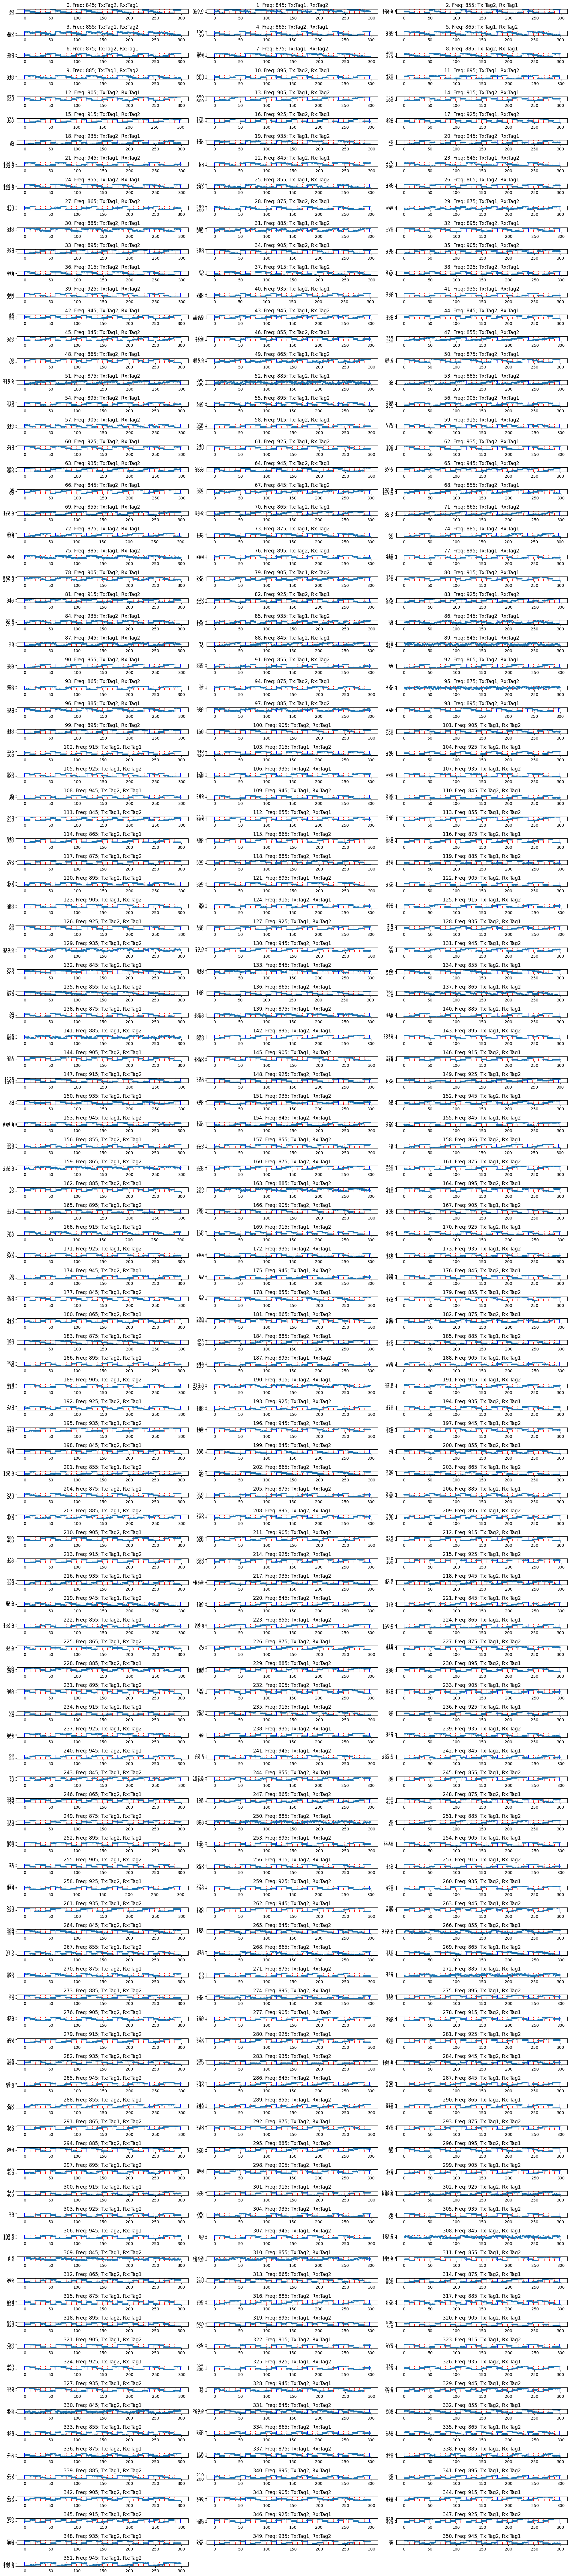

In [3]:
time_per_phase = 10/1000  # s
num_phases=6
default_MPPs=5
num_mpps=df_all.iloc[0]['NumMPPs']*default_MPPs
sampling_rate=1000
plotting=True
ver_lines = [0] + [ (time_per_phase-time_per_phase*0.01) * sampling_rate * (i + 1) for i in range(num_phases*num_mpps)]

processedDF=pd.DataFrame(columns=["Rx","Tx", "Voltages (mV)", "Phase1","Phase3","Phase4","Phase6","Phase7","Phase8",
                                "Frequency (MHz)", "Run Exp Num", "NumMPPs"])
processedDF_aggregated=pd.DataFrame(columns=["Rx","Tx","phase", "median", "std","freq", "dist", 'delta', "Experiment Number", "Unique Exp Number"])

if plotting:
    plt.figure(figsize=(20,90))

unique_exp_no=0
phase_order=[1,3,4,6,7,8]

for df_idx in range(len(df_all)):

    voltages=df_all.iloc[df_idx]['Voltages (mV)']
    phase_medians={
        1:[],
        3:[],
        4:[],
        6:[],
        7:[],
        8:[],
    }
    for idx,v in enumerate(ver_lines):
        if idx<len(ver_lines)-1:
            phase_medians[phase_order[int(idx%num_phases)]].append(np.median(voltages[int(ver_lines[idx]):int(ver_lines[idx+1])]))   
        if plotting:
            plt.subplot(len(df_all)//3+1, 3, df_idx+1)
            if idx%num_phases==0:
                plt.axvline(x=v, color='b', linestyle='-')
            else:
                plt.axvline(x=v, color='r', linestyle='--')
    
    for phase_out_idx in range(len(phase_medians[1])):
        entry={
            "Rx": df_all.iloc[df_idx]["Rx"],
            "Tx":df_all.iloc[df_idx]["Tx"],
            "Voltages (mV)":df_all.iloc[df_idx]["Voltages (mV)"],
            "Phase1":phase_medians[1][phase_out_idx],
            "Phase3":phase_medians[3][phase_out_idx],
            "Phase4":phase_medians[4][phase_out_idx],
            "Phase6":phase_medians[6][phase_out_idx],
            "Phase7":phase_medians[7][phase_out_idx],
            "Phase8":phase_medians[8][phase_out_idx],
            "Frequency (MHz)":df_all.iloc[df_idx]["Frequency (MHz)"],
            "Run Exp Num":df_all.iloc[df_idx]["Run Exp Num"],
            # "Tape Dist (m)":df_all.iloc[df_idx]["Tape dist"],
            # "Laser Dist (m)":df_all.iloc[df_idx]["Laser dist"],
            "Dist (m)":1.185,
            "NumMPPs":df_all.iloc[df_idx]["NumMPPs"],
        }
        processedDF=pd.concat([processedDF,pd.DataFrame([entry])],ignore_index=True)
        # print("Yo",phase_out_idx)
        # print(phase_medians)
        
    for phase in phase_order:
        entry_aggregated={
            "Rx":df_all.iloc[df_idx]["Rx"],
            "Tx":df_all.iloc[df_idx]["Tx"],
            "phase": str(phase),
            "median": np.mean(phase_medians[phase]), # mean of medians
            "std": np.std(phase_medians[phase]),
            "freq": df_all.iloc[df_idx]["Frequency (MHz)"]*1e6,
            "dist":1.185,
            'delta': max(phase_medians[phase])-min(phase_medians[phase]),
            "Experiment Number":df_all.iloc[df_idx]["Run Exp Num"],
            "Unique Exp Number":unique_exp_no,
            "allVoltages": phase_medians[phase]
        }
        processedDF_aggregated=pd.concat([processedDF_aggregated, pd.DataFrame([entry_aggregated])], ignore_index=True)
    unique_exp_no+=1
    
    # Identify and print bad MPPs
    # bad=False
    # for k in phase_medians.keys():
    #     assert(len(phase_medians[k])==num_mpps)
    #     if np.std(phase_medians[k])>1:
    #         d=1.185
    #         print(f"<== Bad data found at {df_idx} df_idx at phase {k} at T2T dist {d}.", end="\t")
    #         print(f"Num vals: {len(phase_medians[k])}, mean: {np.mean(phase_medians[k])}, stdev: {np.std(phase_medians[k])} ==>")
    
    if plotting:
        plt.plot(voltages,'.')
        plt.title(f'{df_idx}. Freq: {df_all.iloc[df_idx]["Frequency (MHz)"]}; Tx:{df_all.iloc[df_idx]["Tx"]}, Rx:{df_all.iloc[df_idx]["Rx"]}')
        plt.ylim([np.percentile(voltages, 1), np.percentile(voltages, 99)])
        plt.tight_layout()
    # break
if plotting:
    plt.savefig("MPPs.pdf")
    

    

In [4]:
with open("processedDF.pkl", 'wb') as f:
    pickle.dump(processedDF,f)
processedDF

,Rx,Tx,Voltages (mV),Phase1,Phase3,Phase4,Phase6,Phase7,Phase8,Frequency (MHz),Run Exp Num,NumMPPs,Dist (m)
0,Tag1,Tag2,"[295.68, 40.86, 40.93, 40.78, 40.63, 40.7, 40....",40.780,38.225,36.545,35.36,35.900,43.105,845,0,1,1.185
1,Tag1,Tag2,"[295.68, 40.86, 40.93, 40.78, 40.63, 40.7, 40....",40.550,37.840,36.165,35.13,35.670,42.725,845,0,1,1.185
2,Tag1,Tag2,"[295.68, 40.86, 40.93, 40.78, 40.63, 40.7, 40....",40.090,37.540,35.705,34.75,35.250,42.495,845,0,1,1.185
3,Tag1,Tag2,"[295.68, 40.86, 40.93, 40.78, 40.63, 40.7, 40....",39.790,37.190,35.590,34.68,35.210,42.380,845,0,1,1.185
4,Tag1,Tag2,"[295.68, 40.86, 40.93, 40.78, 40.63, 40.7, 40....",39.750,37.230,35.595,34.64,35.210,42.310,845,0,1,1.185
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1755,Tag2,Tag1,"[522.58, 192.61, 193.22, 192.91, 192.76, 193.2...",192.990,194.325,195.315,198.06,198.785,197.760,945,15,1,1.185
1756,Tag2,Tag1,"[522.58, 192.61, 193.22, 192.91, 192.76, 193.2...",192.760,194.210,195.200,198.02,198.710,197.450,945,15,1,1.185
1757,Tag2,Tag1,"[522.58, 192.61, 193.22, 192.91, 192.76, 193.2...",192.840,194.440,195.315,198.14,198.900,197.910,945,15,1,1.185
1758,Tag2,Tag1,"[522.58, 192.61, 193.22, 192.91, 192.76, 193.2...",192.800,194.170,195.200,197.91,198.710,197.640,945,15,1,1.185


In [5]:
processedDF_aggregated

,Rx,Tx,phase,median,std,freq,dist,delta,Experiment Number,Unique Exp Number,allVoltages
0,Tag1,Tag2,1,40.192,0.410190,845000000.0,1.185,1.030,0,0,"[40.78, 40.55, 40.09, 39.79, 39.75]"
1,Tag1,Tag2,3,37.605,0.389024,845000000.0,1.185,1.035,0,0,"[38.224999999999994, 37.84, 37.54, 37.19, 37.2..."
2,Tag1,Tag2,4,35.920,0.377200,845000000.0,1.185,0.955,0,0,"[36.545, 36.165000000000006, 35.705, 35.59, 35..."
3,Tag1,Tag2,6,34.912,0.283648,845000000.0,1.185,0.720,0,0,"[35.36, 35.13, 34.75, 34.68, 34.64]"
4,Tag1,Tag2,7,35.448,0.284984,845000000.0,1.185,0.690,0,0,"[35.9, 35.67, 35.25, 35.21, 35.21]"
...,...,...,...,...,...,...,...,...,...,...,...
2107,Tag2,Tag1,3,194.271,0.099116,945000000.0,1.185,0.270,15,351,"[194.325, 194.21, 194.44, 194.17000000000002, ..."
2108,Tag2,Tag1,4,195.246,0.056338,945000000.0,1.185,0.115,15,351,"[195.315, 195.2, 195.315, 195.2, 195.2]"
2109,Tag2,Tag1,6,198.030,0.074297,945000000.0,1.185,0.230,15,351,"[198.06, 198.02, 198.14, 197.91, 198.02]"
2110,Tag2,Tag1,7,198.740,0.100449,945000000.0,1.185,0.305,15,351,"[198.78500000000003, 198.71, 198.9, 198.709999..."


In [6]:
# freq_range=np.array(range(775,1000,10))*1e6
# all_freqs, all_freqs_unwrapped, all_freqs_theoretical, all_freqs_theoretical_unwrapped, all_errors, \
#     selected_experiments_all = multidist_multifreq_phase_estimation(freq_range,processedDF_aggregated,correction_factor=0,plot=True)

# with open("no_correction_all_errs.pkl",'wb') as f:
#     pickle.dump(all_errors,f)
    
# with open("no_correction_all_phases.pkl",'wb') as f:
#     pickle.dump(all_freqs,f)

# with open("no_correction_all_phases_unwrapped.pkl",'wb') as f:
#     pickle.dump(all_freqs_unwrapped,f)    

# with open("theoretical_phase.pkl",'wb') as f:
#     pickle.dump(all_freqs_theoretical,f)    

### With offset correction using the ground truth.

In [7]:
# correction_offsets={}
# all_errors=None


# all_freqs, all_freqs_unwrapped, all_freqs_theoretical, all_freqs_theoretical_unwrapped, _,_=\
#     multidist_multifreq_phase_estimation(freq_range,processedDF_aggregated,correction_factor=0,plot=False)


# for freq in freq_range:
#     offset,best_error,errors=get_offset(all_freqs[freq],freq)
#     # print(f"Freq {freq//1e6};\t Mean:{np.mean(errors)};\t Median:{np.median(errors)};\t Std:{np.std(errors)}")
#     # if all_errors is None:
#     #     all_errors=errors
#     # else:
#     #     all_errors=np.concat((all_errors,errors))
#     correction_offsets[freq]=offset



# all_freqs, all_freqs_unwrapped, all_freqs_theoretical, all_freqs_theoretical_unwrapped, all_errors,_=\
#     multidist_multifreq_phase_estimation(freq_range,processedDF_aggregated,correction_factor=correction_offsets,plot=True)


# with open("gt_correction_all_errs.pkl",'wb') as f:
#     pickle.dump(all_errors,f)
    
# with open("gt_correction_all_phases.pkl",'wb') as f:
#     pickle.dump(all_freqs,f)

# with open("gt_correction_all_phases_unwrapped.pkl",'wb') as f:
#     pickle.dump(all_freqs_unwrapped,f)    

### With correction offsets from pretrained

In [8]:
# correction_offsets=pickle.load(open("/Users/manavjeet/git/T2TExperiments/DistExperiments/correction_offsets.pkl",'rb'))

# all_freqs, all_freqs_unwrapped, all_freqs_theoretical, all_freqs_theoretical_unwrapped, all_errors,_=\
#     multidist_multifreq_phase_estimation(freq_range,processedDF_aggregated,correction_factor=correction_offsets,plot=True)


# with open("pretrained_correction_all_errs.pkl",'wb') as f:
#     pickle.dump(all_errors,f)
    
# with open("pretrained_correction_all_phases.pkl",'wb') as f:
#     pickle.dump(all_freqs,f)

# with open("pretrained_correction_all_phases_unwrapped.pkl",'wb') as f:
#     pickle.dump(all_freqs_unwrapped,f)